# Paytm Daily Transaction Analyzer
### Mini Analytics Dashboard - Pandas + Matplotlib Edition

## 1. Imports and Configuration

In [23]:
%pip install pandas
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Inline charts render inside the notebook
%matplotlib inline

# Clean float display throughout all DataFrames
pd.set_option('display.float_format', '{:,.2f}'.format)

# Transactions above this are flagged as high-value
HIGH_VALUE_THRESHOLD = 10_000

CHART_WINDOW     = 10          # last N transactions shown in the amount bar chart
VALID_TYPES      = ('credit', 'debit')
VALID_CATEGORIES = ('food', 'travel', 'bills', 'other')

# Colour palette used consistently across all charts
COLOR_CREDIT  = '#2ecc71'   # green  - money coming in
COLOR_DEBIT   = '#e74c3c'   # red    - money going out
COLOR_NEUTRAL = '#3498db'   # blue   - neutral / mixed charts
COLOR_HV      = '#e67e22'   # orange - high-value highlight

Setup complete.


## 2. Input Functions


In [ ]:
def get_amount():
    # Keep prompting until the user enters a positive number
    while True:
        raw = input('  Amount (Rs): ').strip().replace(',', '')
        try:
            amount = float(raw)
        except ValueError:
            print('  ERROR: Enter a valid number.')
            continue
        if amount <= 0:
            print('  ERROR: Amount must be greater than zero.')
            continue
        return amount


def get_type():
    # Accept only 'credit' or 'debit'; reject everything else
    while True:
        raw = input('  Type (credit/debit): ').strip().lower()
        if raw in VALID_TYPES:
            return raw
        print(f'  ERROR: Enter one of: {", ".join(VALID_TYPES)}.')


def get_category():
    # Accept one of the four defined spending categories
    while True:
        raw = input('  Category (food/travel/bills/other): ').strip().lower()
        if raw in VALID_CATEGORIES:
            return raw
        print(f'  ERROR: Enter one of: {", ".join(VALID_CATEGORIES)}.')


Input helpers ready.


## 3. Collect Transactions
Run this cell and enter transactions one by one. Type `done` to finish.

In [26]:
records = []
running_credits = 0.0
running_debits  = 0.0

print('+--------------------------------------------------+')
print('|      PAYTM - DAILY TRANSACTION ANALYZER          |')
print('+--------------------------------------------------+')
print("  Enter transactions. Type 'done' when finished.\n")

# Accept transactions in a while loop until the user types 'done'
while True:
    cmd = input("Add transaction (or 'done'): ").strip().lower()

    # 'done' exits the data-entry loop
    if cmd == 'done':
        break

    # Ignore accidental blank Enter presses
    if not cmd:
        continue

    amount   = get_amount()
    txn_type = get_type()
    category = get_category()

    # Flag amounts above the threshold immediately on entry
    is_high_value = amount > HIGH_VALUE_THRESHOLD
    if is_high_value:
        print(f'  ALERT: High-value transaction: Rs{amount:,.0f}')

    # Store each transaction as a dict; loaded into a DataFrame in the next cell
    records.append({
        'amount':     amount,
        'type':       txn_type,
        'category':   category,
        'high_value': is_high_value,
    })

    # Update running totals to show a live balance without re-scanning the list
    if txn_type == 'credit':
        running_credits += amount
    else:
        running_debits += amount

    net = running_credits - running_debits
    print(f'  Recorded. Running balance: Rs{net:+,.2f}\n')

if records:
    print(f'\nCollection done. {len(records)} transaction(s) recorded.')
else:
    print('No transactions entered.')

+--------------------------------------------------+
|      PAYTM - DAILY TRANSACTION ANALYZER          |
+--------------------------------------------------+
  Enter transactions. Type 'done' when finished.

  Recorded. Running balance: Rs+5,000.00

  Recorded. Running balance: Rs+6,000.00

  ALERT: High-value transaction: Rs15,000
  Recorded. Running balance: Rs-9,000.00

  Recorded. Running balance: Rs-4,000.00

  ALERT: High-value transaction: Rs15,000
  Recorded. Running balance: Rs-19,000.00


Collection done. 5 transaction(s) recorded.


## 4. Build DataFrame

In [27]:
# Load all records into a DataFrame; index starts at 1 for readability
df = pd.DataFrame(records)
df.index = pd.RangeIndex(start=1, stop=len(df) + 1)
df.index.name = 'No'

# Derived columns used across multiple cells
df['amount_display'] = df['amount'].apply(lambda x: f'Rs {x:,.2f}')

print(f'DataFrame shape: {df.shape}')
df[['amount_display', 'type', 'category', 'high_value']].rename(
    columns={'amount_display': 'Amount', 'type': 'Type',
             'category': 'Category', 'high_value': 'High Value'}
)

DataFrame shape: (5, 5)


,Amount,Type,Category,High Value
No,,,,
1,"Rs 5,000.00",credit,food,False
2,"Rs 1,000.00",credit,food,False
3,"Rs 15,000.00",debit,food,True
4,"Rs 5,000.00",credit,travel,False
5,"Rs 15,000.00",debit,bills,True


## 5. Summary Statistics

In [28]:
# Separate credits and debits using pandas boolean indexing
total_credits = df[df['type'] == 'credit']['amount'].sum()
total_debits  = df[df['type'] == 'debit']['amount'].sum()
net_balance   = total_credits - total_debits
highest       = df['amount'].max()
average       = df['amount'].mean()
hv_count      = int(df['high_value'].sum())   # True sums as 1 in pandas

balance_label = 'SURPLUS' if net_balance >= 0 else 'DEFICIT'

# Render as a named Series so it displays as a clean single-column table
summary = pd.Series({
    'Total Transactions':              len(df),
    'Total Credits (Rs)':              total_credits,
    'Total Debits (Rs)':               total_debits,
    f'Net Balance - {balance_label} (Rs)': net_balance,
    'Highest Transaction (Rs)':        highest,
    'Average Transaction (Rs)':        average,
    'High-Value Txns (> Rs 10,000)':   hv_count,
}, name='Value')

summary

Total Transactions                    5.00
Total Credits (Rs)               11,000.00
Total Debits (Rs)                30,000.00
Net Balance - DEFICIT (Rs)      -19,000.00
Highest Transaction (Rs)         15,000.00
Average Transaction (Rs)          8,200.00
High-Value Txns (> Rs 10,000)         2.00
Name: Value, dtype: float64

## 6. Chart 1 - Transaction Amounts (Bar Chart)
Each bar shows the amount per transaction. Credits are green, debits are red. High-value bars are outlined in orange.

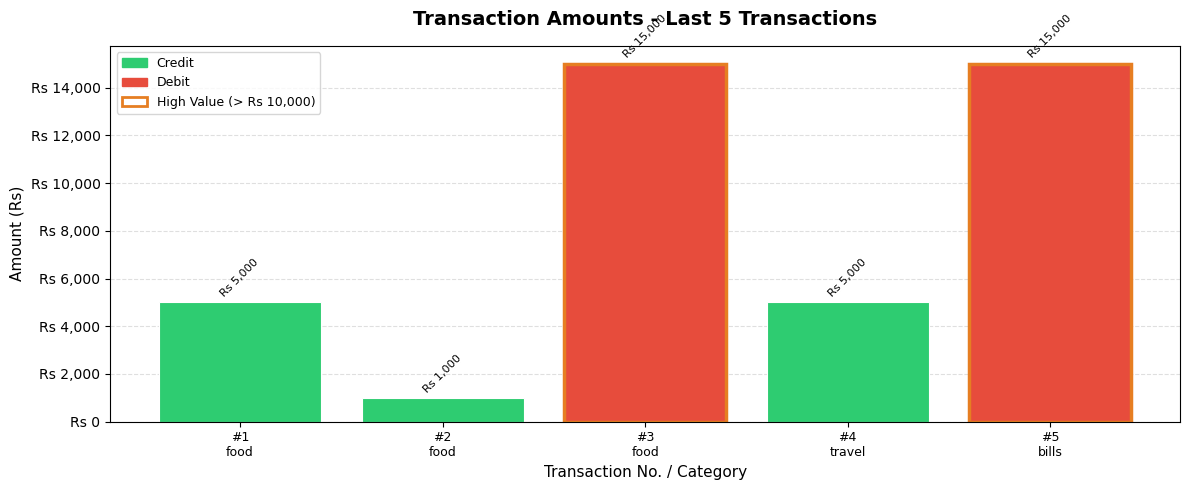

In [29]:
recent = df.tail(CHART_WINDOW).copy()

# Assign a bar colour based on transaction type
colors = [COLOR_CREDIT if t == 'credit' else COLOR_DEBIT for t in recent['type']]

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(range(len(recent)), recent['amount'], color=colors, edgecolor='white', linewidth=0.8)

# Outline high-value bars in orange so they stand out
for i, (bar, is_hv) in enumerate(zip(bars, recent['high_value'])):
    if is_hv:
        bar.set_edgecolor(COLOR_HV)
        bar.set_linewidth(2.5)

# Annotate each bar with its formatted amount
for i, (bar, amt) in enumerate(zip(bars, recent['amount'])):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + recent['amount'].max() * 0.01,
        f'Rs {amt:,.0f}',
        ha='center', va='bottom', fontsize=8, rotation=45
    )

# Label x-axis ticks with transaction number and category
ax.set_xticks(range(len(recent)))
ax.set_xticklabels(
    [f"#{idx}\n{row['category']}" for idx, row in recent.iterrows()],
    fontsize=9
)

ax.set_title(f'Transaction Amounts - Last {len(recent)} Transactions', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Amount (Rs)', fontsize=11)
ax.set_xlabel('Transaction No. / Category', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rs {x:,.0f}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# Build a legend manually so colours are explained
legend_handles = [
    mpatches.Patch(color=COLOR_CREDIT, label='Credit'),
    mpatches.Patch(color=COLOR_DEBIT,  label='Debit'),
    mpatches.Patch(facecolor='white', edgecolor=COLOR_HV, linewidth=2, label='High Value (> Rs 10,000)'),
]
ax.legend(handles=legend_handles, fontsize=9)

plt.tight_layout()
plt.show()

## 7. Chart 2 - Credit vs Debit Comparison (Grouped Bar Chart)

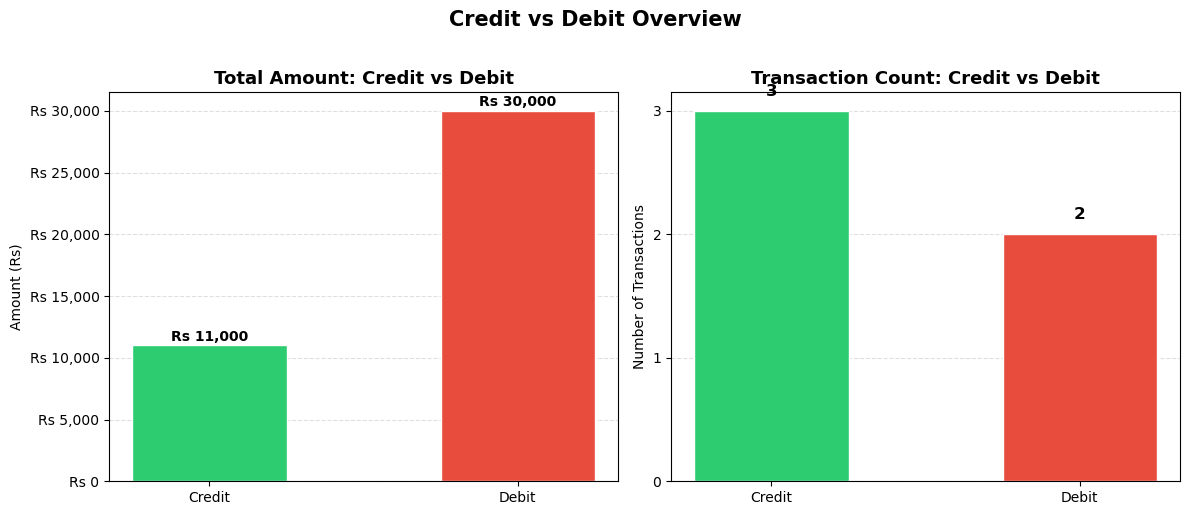

In [30]:
# Aggregate totals and counts for credit vs debit
credit_total = df[df['type'] == 'credit']['amount'].sum()
debit_total  = df[df['type'] == 'debit']['amount'].sum()
credit_count = int((df['type'] == 'credit').sum())
debit_count  = int((df['type'] == 'debit').sum())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left chart: total amount comparison
bars1 = ax1.bar(['Credit', 'Debit'], [credit_total, debit_total],
                color=[COLOR_CREDIT, COLOR_DEBIT], width=0.5, edgecolor='white')
for bar, val in zip(bars1, [credit_total, debit_total]):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + credit_total * 0.01,
             f'Rs {val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_title('Total Amount: Credit vs Debit', fontsize=13, fontweight='bold')
ax1.set_ylabel('Amount (Rs)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rs {x:,.0f}'))
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.set_axisbelow(True)

# Right chart: transaction count comparison
bars2 = ax2.bar(['Credit', 'Debit'], [credit_count, debit_count],
                color=[COLOR_CREDIT, COLOR_DEBIT], width=0.5, edgecolor='white')
for bar, val in zip(bars2, [credit_count, debit_count]):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
             str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
ax2.set_title('Transaction Count: Credit vs Debit', fontsize=13, fontweight='bold')
ax2.set_ylabel('Number of Transactions')
ax2.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.set_axisbelow(True)

plt.suptitle('Credit vs Debit Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Chart 3 - Cumulative Balance Over Time (Line Chart)

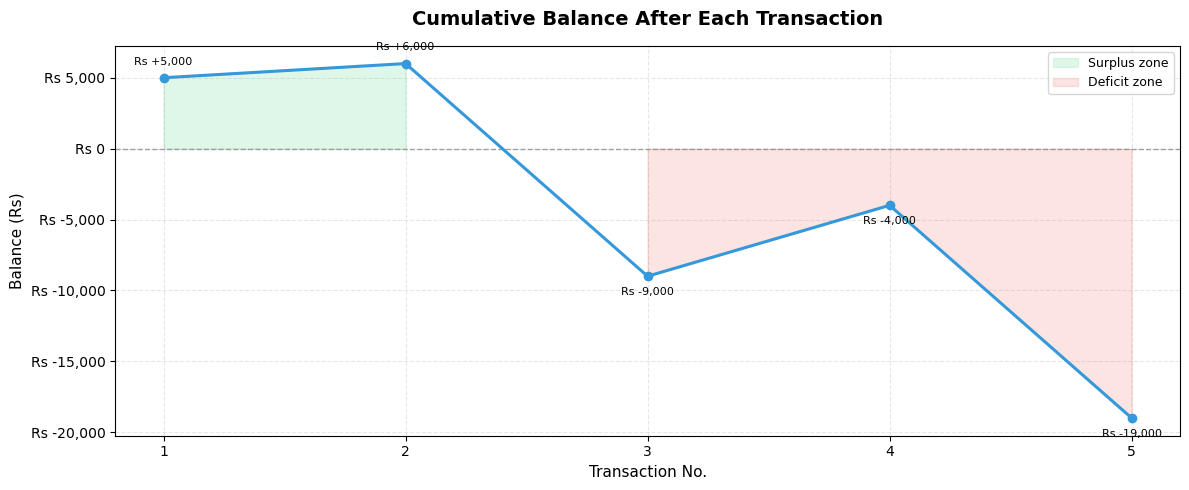

In [31]:
# Assign +amount for credits and -amount for debits to compute a running balance
df['signed_amount'] = df.apply(
    lambda row: row['amount'] if row['type'] == 'credit' else -row['amount'],
    axis=1
)
# cumsum() accumulates the signed amount row by row to track balance over time
df['balance'] = df['signed_amount'].cumsum()

fig, ax = plt.subplots(figsize=(12, 5))

# Fill area above/below zero with different colours to show surplus vs deficit
ax.fill_between(df.index, df['balance'], 0,
                where=(df['balance'] >= 0), alpha=0.15, color=COLOR_CREDIT, label='Surplus zone')
ax.fill_between(df.index, df['balance'], 0,
                where=(df['balance'] < 0),  alpha=0.15, color=COLOR_DEBIT,  label='Deficit zone')

# Main balance line
ax.plot(df.index, df['balance'], color=COLOR_NEUTRAL, linewidth=2.2, marker='o', markersize=6, zorder=3)

# Annotate each data point with its running balance
for idx, bal in zip(df.index, df['balance']):
    offset = df['balance'].abs().max() * 0.04
    va     = 'bottom' if bal >= 0 else 'top'
    ax.annotate(
        f'Rs {bal:+,.0f}',
        xy=(idx, bal),
        xytext=(0, 8 if bal >= 0 else -8),
        textcoords='offset points',
        ha='center', va=va, fontsize=8
    )

# Draw a zero baseline so surplus vs deficit is immediately visible
ax.axhline(0, color='grey', linewidth=1, linestyle='--', alpha=0.7)

ax.set_title('Cumulative Balance After Each Transaction', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Transaction No.', fontsize=11)
ax.set_ylabel('Balance (Rs)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rs {x:,.0f}'))
ax.set_xticks(df.index)
ax.grid(linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 9. Chart 4 - High-Value vs Normal Transactions (Stacked Bar by Category)

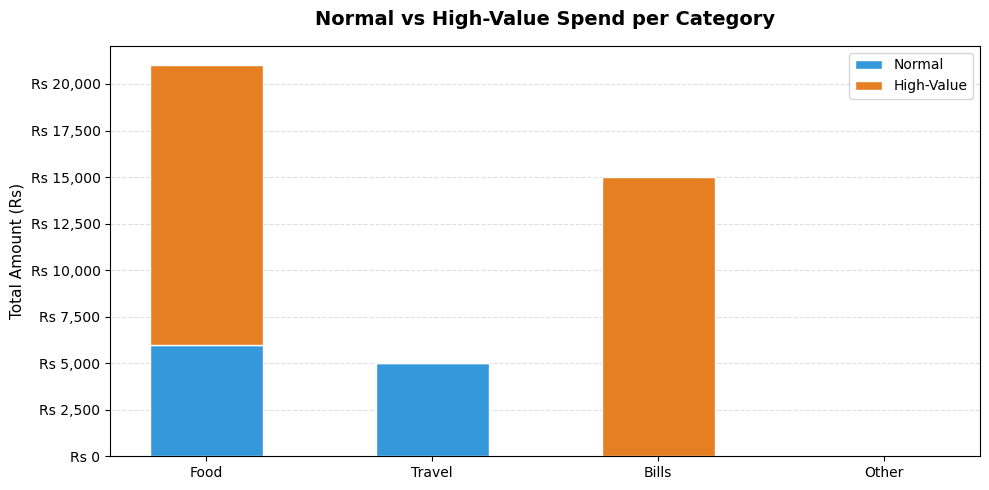

In [32]:
# Pivot to get normal and high-value totals per category side by side
pivot = (
    df.groupby(['category', 'high_value'])['amount']
    .sum()
    .unstack(fill_value=0)
    .reindex(VALID_CATEGORIES, fill_value=0)
)
# Rename columns so the legend is readable
pivot.columns = [
    'Normal (Rs)' if col == False else 'High-Value (Rs)'
    for col in pivot.columns
]

fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(pivot))
bar_width = 0.5

# Stacked bar: normal portion on the bottom, high-value stacked on top
normal_bars = ax.bar(x, pivot.get('Normal (Rs)', 0),
                     width=bar_width, label='Normal',     color=COLOR_NEUTRAL, edgecolor='white')
hv_bars     = ax.bar(x, pivot.get('High-Value (Rs)', 0),
                     width=bar_width, label='High-Value', color=COLOR_HV,      edgecolor='white',
                     bottom=pivot.get('Normal (Rs)', 0))

ax.set_xticks(list(x))
ax.set_xticklabels([c.capitalize() for c in pivot.index], fontsize=10)
ax.set_title('Normal vs High-Value Spend per Category', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Total Amount (Rs)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rs {x:,.0f}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 10. High-Value Transaction Table

In [33]:
# Filter rows flagged as high-value; drop the redundant boolean column
hv_df = df[df['high_value']].copy()

if hv_df.empty:
    print('No high-value transactions recorded.')
else:
    hv_df = hv_df.drop(columns=['high_value', 'signed_amount', 'balance', 'amount_display'])
    hv_df.index.name = 'No'
    hv_df['amount'] = hv_df['amount'].apply(lambda x: f'Rs {x:,.2f}')
    hv_df.columns = ['Amount', 'Type', 'Category']
    print(f'{len(hv_df)} high-value transaction(s) flagged (> Rs {HIGH_VALUE_THRESHOLD:,}):')
    display(hv_df)

2 high-value transaction(s) flagged (> Rs 10,000):


,Amount,Type,Category
No,,,
3,"Rs 15,000.00",debit,food
5,"Rs 15,000.00",debit,bills


## 11. Descriptive Statistics

In [34]:
# pandas describe() computes count, mean, std, percentiles and max in one call
desc = df['amount'].describe().rename({
    'count': 'Count',
    'mean':  'Mean',
    'std':   'Std Dev',
    'min':   'Min',
    '25%':   '25th Percentile',
    '50%':   'Median',
    '75%':   '75th Percentile',
    'max':   'Max',
})

print('Amount Column - Descriptive Statistics')
print('=' * 40)
for label, value in desc.items():
    if label == 'Count':
        print(f'  {label:<22}: {int(value)}')
    else:
        print(f'  {label:<22}: Rs {value:>10,.2f}')

Amount Column - Descriptive Statistics
  Count                 : 5
  Mean                  : Rs   8,200.00
  Std Dev               : Rs   6,418.72
  Min                   : Rs   1,000.00
  25th Percentile       : Rs   5,000.00
  Median                : Rs   5,000.00
  75th Percentile       : Rs  15,000.00
  Max                   : Rs  15,000.00
